# **Week 5: Introduction to Random Variables**

```
.------------------------------------.
|   __  ____  ______  _  ___ _____   |
|  |  \/  \ \/ / __ )/ |/ _ \___  |  |
|  | |\/| |\  /|  _ \| | | | | / /   |
|  | |  | |/  \| |_) | | |_| |/ /    |
|  |_|  |_/_/\_\____/|_|\___//_/     |
'------------------------------------'

```


# Warm-up activity
Suppose $X$ is a random variable measured in hours. We convert it to minutes by defining $Y = 60X$. Discuss with the people next to you what will happen to:  

a) the mean of $Y$

b) the variance of $Y$

c) the median of $Y$

d) the shape of the distribution of $Y$

<details>
<summary>▶️ Click to show the solution</summary>

a) We have $\mathbb{E}(Y) = \mathbb{E}(60X) = 60 \mathbb{E}(X)$. In other words, the mean is multiplied by 60.

b) For the variance, we have $\text{Var}(Y) = \text{Var}(60X) = 60^2 \text{Var}(X)$. The variance of $Y$ is 3600 times the variance of $X$.

c) The median of $Y$ will be the median of $X$ multiplied by a factor of 60.

d) The distribution shape will be the same, but all values will be scaled by a factor of 60.

</details>

## **Pre-Configurating the Notebook**

### **Switching to the R Kernel on Colab**

By default, Google Colab uses Python as its programming language. To use R instead, you’ll need to manually switch the kernel by going to **Runtime > Change runtime type**, and selecting R as the kernel. This allows you to run R code in the Colab environment.

However, our notebook is already configured to use R by default. Unless something goes wrong, you shouldn’t need to manually change runtime type.

### **Importing Required Packages**
**Run the following lines of code**:

In [1]:
#Do not modify

setwd("/content")

# Remove `MXB107-Notebooks` if exists,
if (dir.exists("MXB107-Notebooks")) {
  system("rm -rf MXB107-Notebooks")
}

# Fork the repository
system("git clone https://github.com/ArwenNugteren/MXB107-Notebooks")

# Change working directory to "MXB107-Notebooks"
setwd("MXB107-Notebooks")

#
invisible(source("R/preConfigurated.R"))

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr

Loading required package: stringr

Loading required package: magrittr


Attaching package: ‘magrittr’


The following object is masked from ‘package:tidyr’:

    extract


Loading required package: IRdisplay

Loading required package: png

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘png’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: grid

Loading required package: knitr

Loading required package: jpeg

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘jpeg’”
I

**Do not modify the following**

In [2]:
if (!require("testthat")) install.packages("testthat"); library("testthat")

test_that("Test if all packages have been loaded", {

  expect_true(all(c("ggplot2", "tidyr", "dplyr", "stringr", "magrittr", "knitr") %in% loadedNamespaces()))

})

Loading required package: testthat


Attaching package: ‘testthat’


The following objects are masked from ‘package:magrittr’:

    equals, is_less_than, not




Test passed with 1 success 😸.


# Random variables and probability distributions

## Question 1
The number of days in a week on which a business receives at least one complaint, $X$, is a random variable with the following distribution.

\begin{align*}
		\begin{array}{l|cccccccc}
		x & 0 & 1& 2 & 3 & 4 & 5 & 6 & 7 \\\hline
		Pr(X=x) & 0.08 & 0.32 & 0.3 & 0.13 & 0.1 & 0.04 & 0.02 & 0.01
		\end{array}
		\end{align*}


a) Find the expected number of days in a week on which a business receives at least one complaint.

b) Find the variance and standard deviation of the number of days in a week on which a business receives at least one complaint.

<details>
<summary>▶️ Click to show the solution</summary>

a) \begin{align*}
 					\mathbb{E}(X) &= \sum_x x Pr(X = x),\\
 						&= (0 \times 0.08) + (1 \times 0.32) + (2 \times 0.3) + (3 \times 0.13) + (4 \times 0.1)\\&\quad + (5 \times 0.04) + (6 \times 0.02) + (7 \times 0.01),\\
 						&= 2.1.
 				\end{align*}
        The expected number of days in a week on which a business receives at least one complaint is 2.1 days.

b) \begin{align*}
 					\text{Var}(X) &= \mathbb{E}(X^2) - [\mathbb{E}(X)]^2,\\
 					\mathbb{E}(X^2) &= \sum_x x^2 Pr(X = x),\\
 						&= (0 \times 0.08) + (1 \times 0.32) + (4 \times 0.3) + (9 \times 0.13)  + (16 \times 0.1)\\&\quad + (25 \times 0.04) + (36 \times 0.02) + (49 \times 0.01),\\
 						&= 6.5.\\
 					\text{Therefore, }\text{Var}(X) &= 6.5 - 2.1^2 = 2.09. \\
          \text{ and, } \text{sd}(X) & = \sqrt{\text{Var}(X)} = \sqrt{2.09} \approx 1.45
 				\end{align*}
        The variance of the number of days in a week on which a business receives at least one complaint is 6.5 days squared, corresponding to a standard deviation of 1.45 days.

</details>

## Question 2
Let $X$ be the number of students who show up for a professor’s consultation session on a particular day. Suppose that the pmf of $X$ is $Pr(X=0)=0.20$, $Pr(X=1)=0.25$, $Pr(X=2)=0.30$, $Pr(X=3)=0.15$, and $Pr(X=4)=0.10$.


a) Draw the corresponding probability table.

b) What is the probability that at least two students show up? More than two students show up?

c) What is the probability that between one and three students, inclusive, show up?

d) What is the expected number of students showing up to consultation?

<details>
<summary>▶️ Click to show the solution</summary>

a) \begin{align*}
				\begin{array}{l|cccccc}
				x & 0 & 1& 2 & 3 & 4\\\hline
				P(X=x) & 0.20 & 0.25 & 0.30 & 0.15 & 0.10
				\end{array}
			\end{align*}


b) We are looking for $Pr(X \ge 2)$ (the probability that *at least two* students show up) and $Pr(X > 2)$ (the probability that *more than two* students show up).
\begin{align*}
					Pr(X \ge 2) &= Pr(X = 2) + Pr(X = 3) + Pr(X = 4), \\
							&= 0.30 + 0.15 + 0.1,\\
							&= 0.55.\\
					Pr(X > 2) &= Pr(X \ge 2) - Pr(X = 2),\\
							&= 0.55 - 0.3 \\
							&= 0.25.
\end{align*}
The probability that at least 2 students show up is 0.55, and the probability that more than 2 students show up is 0.25.

c) We are looking for $Pr(1 \le X \le 3)$:

\begin{align*}
					Pr(1 \le X \le 3) &= Pr(X = 1) + Pr(X = 2) + Pr(X = 3),\\
							&= 0.25 + 0.3 + 0.15,\\
							&= 0.7.
\end{align*}
The probability that between 1 and 3 students show up is 0.7.


d) \begin{align*}
 					\mathbb{E}(X) &= \sum_x x Pr(X = x),\\
 						&= (0 \times 0.2) + (1 \times 0.25) + (2 \times 0.3) + (3 \times 0.15) + (4 \times 0.1),\\
 						&= 1.7.
 				\end{align*}
The expected number of students showing up is 1.7.
</details>

## Question 3
The probability density function of $X$, the lifespan of a certain type of microelectronic device (calculated in days), is given by
					\begin{align*}
					f(x) &= \dfrac{10}{x^2},\quad x > 10.
				\end{align*}

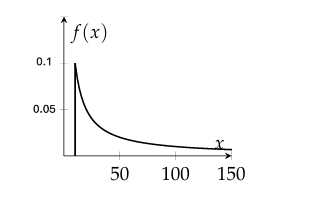

a) Calculate $Pr(X>20)$.

b) What is the median?

c) What is the cumulative distribution function of $X$, $F(x)$?

d) What is the quantile function, $Q(p)$?

e) Using your answer to (d), find the lower quartile.

<details>
<summary>▶️ Click to show the solution</summary>

a) \begin{align*}
 					Pr(X > 20) = \int_{20}^\infty f(x) dx = \int_{20}^\infty \dfrac{10}{x^2} dx
 							= \left[-\dfrac{10}{x}\right]_{20}^\infty
 							= \dfrac{1}{2}
 				\end{align*}


b) From (a), we know that $Pr(X > 20) = 0.5$, so the median is 20, $m = 20$.


c) \begin{align*}
 					F(x) = Pr(X < x) &= \int_{10}^x f(u) du
 						= \int_{10}^x \dfrac{10}{u^2} du
 						= \left[-\dfrac{10}{u}\right]_{10}^x
 						= -\dfrac{10}{x} + \dfrac{10}{10},\\
 						&= 1 - \dfrac{10}{x} \quad \text{for } x > 10.
 			\end{align*}

d) $Q(p) = F^{-1}(p)$. To find, consider,
 			\begin{align*}
 				p &= F(x) = 1 - \dfrac{10}{x},\\
 				\Rightarrow 1 - p &= \dfrac{10}{x},\\
 				\Rightarrow x &= \dfrac{10}{1 - p},\\
 				\therefore Q(p) &= \dfrac{10}{1 - p}.
 			\end{align*}

e) The lower quartile, $Q_1$, is defined by $Pr(X < Q_1) = 0.25 \Leftrightarrow Q_1 = Q(0.25)$.
			\begin{align*}
				Q_1 = Q(0.25) = \dfrac{10}{1 - 0.25} = \dfrac{40}{3} \approx 13.33.
			\end{align*}

</details>

## Question 4
Suppose the error $X$ (in cm) in a measuring process has a probability density function given by

\begin{align*}
				f(x) = 2(1-x), \quad 0\leq x\leq 1.
				\end{align*}
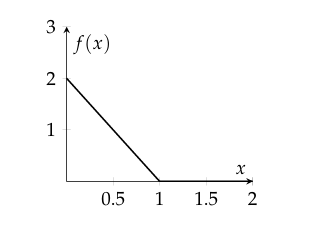

a) Find the mean value of the error.

b) Find the variance of the error.

c) Show that the median error is smaller than the mean error (you do not have to calculate the median to show this). Why is this not surprising for this pdf?

d) Give the mean and variance of the error when it is measured in millimeters.

<details>
<summary>▶️ Click to show the solution</summary>

a) \begin{align*}
 					\mathbb{E}(X) &= \int_{-\infty}^\infty xf(x) dx
 						= \int_0^1 (2x - 2x^2) dx
 						= \left[x^2 - \dfrac{2x^3}{3}\right]_0^1
 						= (1 - \dfrac{2}{3}) - 1
 						= \dfrac{1}{3}
 				\end{align*}
The mean error is $\frac13$ cm.


b) \begin{align*}
					\text{Var}(X) &= \mathbb{E}(X^2) - [\mathbb{E}(X)]^2,\\
 					\mathbb{E}(X^2) &= \int_{-\infty}^\infty x^2f(x) dx
 						= \int_0^1 (2x^2 - 2x^3) dx
 						= \left[\dfrac{2x^3}{3} - \dfrac{x^4}{2}\right]_0^1
 						= \left[\dfrac{2}{3} - \dfrac{1}{2}\right] - 0
 						= \dfrac{1}{6}.\\
 					\Rightarrow \text{Var}(X) &= \dfrac{1}{6} - \left(\dfrac{1}{3}\right)^2
 							 = \dfrac{1}{18}
 				\end{align*}
The variance of the error is $\frac1{18} \text{ cm}^2$.


c) Consider
 				\begin{align*}
 					Pr(X < \mathbb{E}(X)) &= \int_0^{1/3} f(x) dx 						= \int_0^{1/3} 2 (1 - x) dx
 						= \left[2x - x^2\right]_0^{1/3}
 						= \left[\dfrac{2}{3} - \dfrac{1}{3^2}\right] - 0,\\
 						&= \dfrac{5}{9} > 0.5.
 				\end{align*}
 				Since $Pr(X < \mathbb{E}(X)) > 0.5$, we must have that the median, $m < \mathbb{E}(X)$.


d) Now, consider the random variable $Y = 10X$.
 				\begin{align*}
 					\mathbb{E}(Y) &= \mathbb{E}(10X) = 10\mathbb{E}(X) = \dfrac{10}{3} \\
 					\text{Var}(Y) &= \text{Var}(10X) = 10^2\text{Var}(X) = \dfrac{100}{18}
 				\end{align*}
The mean is $\frac{10}3$ mm and the variance is $\frac{100}{18} \text{ mm}^2$.

</details>

## Question 5
The length of time (in hours) required by students to complete a one-hour exam is a random variable with a probability density function given by

\begin{align*}
			f(y) &= cy^2+y,\quad 0\leq y\leq 1.
		\end{align*}

a) Find the value of $c$ that makes $f(y)$ a density function.

b) Find the probability that a randomly selected student will finish in less than half an hour.

c) Find the expected completion time.

d) Find the variance of the completion time.

<details>
<summary>▶️ Click to show the solution</summary>

a) First, consider that we have $0 \leq y \leq 1$.
			\begin{align*}
				1 	&= \int_0^1 f(y) dy
					= \int_0^1 (cy^2 + y) dy
					= \left[\dfrac{cy^3}{3} + \dfrac{y^2}{2} \right]_0^1
					= \dfrac{c}{3} + \dfrac{1}{2},\\
				\Rightarrow \dfrac{1}{2} &= \dfrac{c}{3},\\
				\Rightarrow c &= \dfrac{3}{2}.
			\end{align*}

We see that $f(y) \geq 0$ for all $y \in [0,1]$, and for $c = \frac32$, $\int_y f(y) dy = 1$, so $f(y)$ is a valid pdf if $c = 3/2$.


b) \begin{align*}
 				Pr(Y < 0.5) & = \int_0^{0.5} f(y) dy \\
 					& = \int_0^{0.5} \left(\dfrac{3y^2}{2} + y\right) dy \\
 					& = \left[ \dfrac{y^3}{2} + \dfrac{y^2}{2} \right]_0^{0.5} \\
 					& = \left[\dfrac{(0.5)^3}{2} + \dfrac{(0.5)^2}{2}\right] \\
 					& = \dfrac{3}{16}.
 			\end{align*}
The probability that a random student will finish in less than half an hour is $\frac3{16}$.

c) \begin{align*}
 				\mathbb{E}(Y) &= \int_{-\infty}^\infty y f(y) dy \\
 					&= \int_0^1 \left(\dfrac{3y^3}{2} + y^2\right) dy \\
 					&= \left[ \dfrac{3y^4}{8} + \dfrac{y^3}{3}\right]_0^1 \\
 					&= \left[\dfrac{3}{8} + \dfrac{1}{3}\right] - [0] \\
 					&= \dfrac{17}{24} \text{ hours}.
 			\end{align*}
This gives an expected completion time of $\frac{17}{24}$ hours or 42.5 minutes.


d) \begin{align*}
 				\text{Var}(Y) &= \mathbb{E}(Y^2) - [\mathbb{E}(Y)]^2.\\
 				\mathbb{E}(Y^2) &= \int_{-\infty}^\infty y^2 f(y) dy \\
 					&= \int_0^1 \left(\dfrac{3y^4}{2} + y^3\right) dy \\
 					&= \left[\dfrac{3y^5}{10} + \dfrac{y^4}{4}\right]_0^1 \\
 					&= \left[ \dfrac{3}{10} + \dfrac{1}{4}\right] \\
 					&= \dfrac{11}{20}.\\
 				\therefore \text{Var}(Y) &= \dfrac{11}{20} - \left(\dfrac{17}{24}\right)^2
 					= 0.048 \text{ hours}^2.
 			\end{align*}
We have a variance of 0.048 squared hours in completion time.

</details>

# R coding
When we are working with data, we can consider our data to be realisations of random variables. We can estimate expected values, variances, standard deviations and quantiles from this data and see if it matches up with our mathematical model.

## The bard's "lucky" d6
A Dungeons & Dragons bard claims to own a lucky 6‑sided die that seems to roll high far too often.

You are skeptical about luck, but you (a rogue) sneakily steal the dice and discover that the probability of rolling a number $k$ is proportional to $k$ itself:
$$ Pr(X = k) \propto k, \qquad k=1,2,3,4,5,6$$

In [ ]:
#c is an integer
#1 = 1/c + 2/c + 3/c + 4/c + 5/c + 6/c
#21/c = 1
# therefore, c = 21

### Question 1.1
Write down a table for the pmf and calculate the probabilities of rolling each number. Can you write down a simple expression for each probability?

In [12]:
table(c(1/21,2/21,3/21,4/21,5/21,6/21),1:6)


                    
                     1 2 3 4 5 6
  0.0476190476190476 1 0 0 0 0 0
  0.0952380952380952 0 1 0 0 0 0
  0.142857142857143  0 0 1 0 0 0
  0.19047619047619   0 0 0 1 0 0
  0.238095238095238  0 0 0 0 1 0
  0.285714285714286  0 0 0 0 0 1

<details>
<summary>▶️ Click to show the solution</summary>

The pmf can be summarised in the following table.
\begin{align*}
		\begin{array}{l|cccccccc}
		x  & 1& 2 & 3 & 4 & 5 & 6  \\\hline
		Pr(X=x) & \frac1{21} & \frac{2}{21} & \frac{3}{21}& \frac{4}{21} & \frac{5}{21} & \frac{6}{21}
		\end{array}
		\end{align*}


 The theoretical expression for the probability is:
$$ Pr(X = k) = \frac{k}{1+2+3+4+5+6} = \frac{k}{21}$$

</details>

### Question 1.2
Use R to simulate 10,000 dice rolls using your probability expression, calculate the count of each number, and the proportion that each is rolled.

In [22]:
# define the dice vector of values 1-6
Die <- 1:6
# create a vector with the probabilities of each number 1-6
p <- Die/21
N = 10000
# simulate rolling the dice using sample()
rolls <- sample(Die, N, replace=TRUE, prob = p)
# calculate the count and proportion each value is rolled
count = table(rolls)
proportions <- count/N
print(count)
print(proportions)

rolls
   1    2    3    4    5    6 
 478  930 1467 1912 2317 2896 
rolls
     1      2      3      4      5      6 
0.0478 0.0930 0.1467 0.1912 0.2317 0.2896 


<details>
<summary>▶️ Click to show the solution</summary>

```r
# define the dice
dice <- 1:6

# create a vector with the probabilities of each number 1-6
p <- dice/sum(dice)

# simulate rolling the dice using sample()
n = 10000
rolls <- sample(dice, n, replace=T, prob = p)

# summarise the results
counts <- table(rolls)
proportions <- counts/n
print(proportions)
```

</details>

### Question 1.3
Calculate the expected value, median and quartiles of your simulated dice dataset and plot these in a boxplot. What is the shape of the data?

[1] 4.3329

[1] 5

25% 
  3

75% 
  6

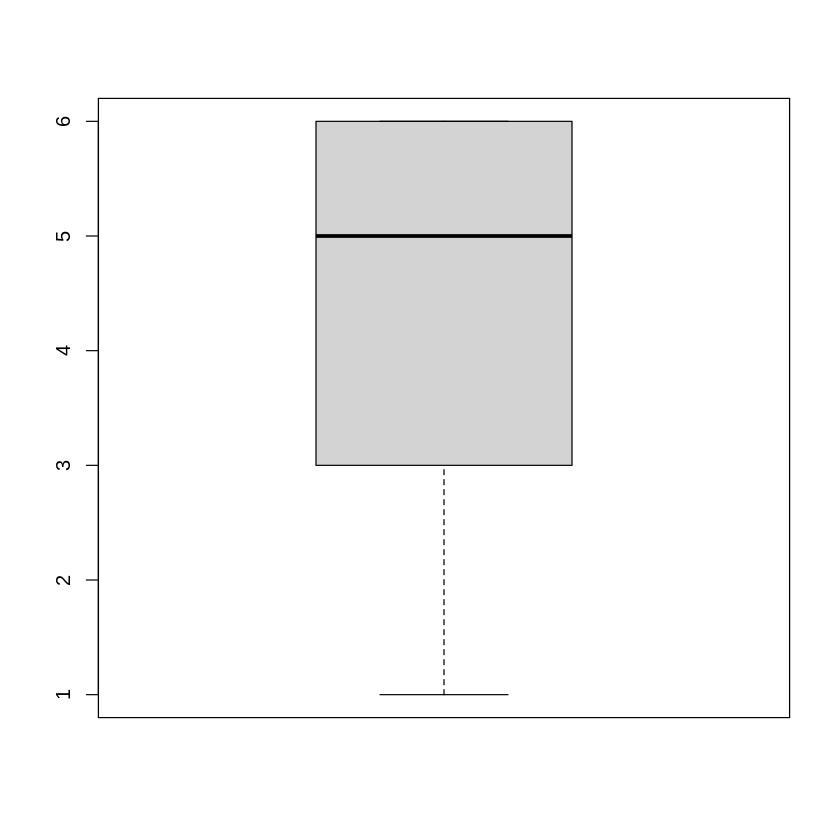

In [20]:
mean(rolls)
median(rolls)
quantile(rolls,0.25)
quantile(rolls,0.75)
boxplot(rolls)



<details>
<summary>▶️ Click to show the solution</summary>

```r
mean(rolls)
median(rolls)
quantile(rolls, 0.25)
quantile(rolls, 0.75)
boxplot(rolls)

# the boxplot shows that the data is left (negatively) skewed
```
</details>

### Question 1.4
Calculate the variance and standard deviation of the sample using R.

In [21]:
var(rolls)
sd(rolls)

[1] 2.200898

[1] 1.483542

<details>
<summary>▶️ Click to show the solution</summary>

```r
var(rolls)
sd(rolls)
```
</details>

# Your turn!
*Work on these questions yourself or in small groups with the people around you.*


## Question 1

The number of days in a working week, $X$, for which a lift has at least some problem has the following distribution

\begin{align*}
		\begin{array}{l|cccccc}
		x & 0 & 1& 2 & 3 & 4 & 5 \\\hline
		P(X=x) & 0.28 & 0.5 & 0.12 & 0.05 & 0.04 & 0.01
		\end{array}
		\end{align*}


a) Find the expected value of $X$.

b) Find the variance and standard deviation of $X$.


<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>


## Question 2
The lifetime in years of a certain type of electronic component has a probability density function (pdf) given by

\begin{align*}
		f(x) = \left\{\begin{array}{ll}
		\dfrac{3x^2}{c} & \text{for }0\leq x\leq 1\\\\
		\dfrac{3}{2x^4} & \text{for }x\geq 1
		\end{array}\right.
		\end{align*}


a) Determine the value of $c$ such that $f(x)$ is a pdf.

b) Find the median lifetime.

c) Find the expected lifetime.

d) Find the probability that the component will last longer than its expected lifetime. What does this tell you about the skewness of the distribution?

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

## Question 3
The following cumulative distribution function of the continuous random variable $Y$ is given by:

\begin{align*}
		F_Y(y) = \left\{\begin{array}{ll}
		0 & y<-5\\
		k(y+5)^2 & -5\leq y\leq 7\\
		1 & y>7
		\end{array}\right.
		\end{align*}

a) What is the value of $k$ that makes $f$ is a valid probability density function?

b) What is the probability $Pr(Y>4)$?

c) What is the probability $Pr (-3<Y<0)$?

d) What the value of $n$ such that $Pr(Y>n) = 2/3$?

e) Find the probability density function, $f_Y(y)$.

f) Find the quantile function, $Q(p)$.

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

## Question 4
The probability density function of $X$ is given by:

\begin{align*}
			f(x) = a+bx^2,\quad 0\leq x< 1.
		\end{align*}

If $\mathbb{E}(X) = 3/5$, find $a$ and $b$.

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

## Question 5

Let $X$ be the time in hours after 8 am when a certain teenager wakes up during holidays.  Suppose the probability density function of $X$ is given by

$$ f(x) = \frac{x}{2},\quad 0\leq x<2 $$

a) Sketch the graph of this function.

b) Find the expected time the teenager will wake up.

c) Find the variance of the teenager’s waking up time.

d) Find the  time for which there is a 50% chance that the teenager will sleep past it during holidays.


<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

## Question 6
Let $X\in[0,1]$ be the time (in hours) a bus arrives after the hour. The bus tends to arrive later rather than earlier, so we model the density as increasing on the interval [0,1]:
\begin{equation} f(x)=\begin{cases}
2x, & 0\le x\le 1\\[2pt]
0, & \text{otherwise}
\end{cases}  \end{equation}


### Question 6.1
What are the expected value and median of the bus times?

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

### Question 6.2
Find the cdf of $f$ and the corresponding quantile function.

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

### Question 6.3
The code below simulates 10,000 values from this distribution and assigns them to the vector `X`.

*If you're interested, this uses a method that we call Inverse Transform Sampling. You don't need to understand the details, but feel free to look it up if you are curious.*

In [ ]:
n = 10000     # the number of simulations
U <- runif(n) # simulating from the uniform distribution (we'll learn about this in two weeks time)
X <- sqrt(U)  # converting the values to our distribution using inverse transform method

Find the mean, median, variance and standard deviations of the bus time data. Is this distribution skewed?

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

### Question 6.4
Choose an appropriate plot to display the bus time data and generate this plot using R.

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>